# 00 - Introduction and Overview

## Trustworthy AI perception in a control loop

Modern driver-assistance and automated-driving systems increasingly replace
hand-engineered perception with *learned* components: a neural network maps camera
pixels to the quantities a controller needs (lane offset, obstacles, other
agents). This works well inside the conditions the network was trained on - its
**operational design domain (ODD)** [1] - and can fail *silently* outside it. A
blurred lens, low sun, an unusual road geometry, or simply an input unlike
anything in the training set can make the network confidently wrong.

The danger is specific to a **closed loop**. A wrong perception estimate is not
just a bad number on a screen; it is fed straight into a controller that acts on
it, and the vehicle moves. So the question this course studies is not "how
accurate is the perception?" but:

> Given an imperfect, learned perception system, **when should we trust it enough
> to close the control loop on it**, and what should happen when we should not?

We answer it with three ingredients, each in its own notebook: a way to *quantify*
perception uncertainty (04-05), a way to *decide* whether the system is inside its
competence (06), and a way to *act* on that decision by sharing authority with a
human driver (07). The same monitoring theme appears in recent work on
perception-system fault detection [9], integrity monitoring of learned detectors
[10], and ODD monitoring under uncertainty [11].

## The system as equations

We study the smallest closed loop that still contains the real difficulty. Symbols
are collected in the notation table near the end.

**Plant.** A vehicle tracking a lane, written in *error coordinates*
$x=[e_y,\,e_\psi]^\top$ (lateral offset [m], heading error [rad]), driven by the
steering angle $u=\delta$, with road curvature $\kappa$ as a measured disturbance:

$$ x_{k+1} = f(x_k,\,u_k,\,\kappa_k). \tag{1} $$

**Perception.** A camera produces an image $\mathcal{I}_k = g(x_k,\,c_k)$ that also
depends on the conditions $c_k$ (brightness, blur, occlusion, curvature). A learned
estimator $h_\theta$ inverts it into an estimate of the state together with a
*self-reported* covariance $R_k^{AI}$ (how uncertain the network believes it is):

$$ \hat y_k = h_\theta(\mathcal{I}_k) \approx C\,x_k, \qquad
   \mathrm{Cov}[\hat y_k] \approx R_k^{AI}. \tag{2} $$

**Controller.** A feedback law acts on an *estimate* of the state,

$$ u_k = \pi(\hat x_k), \tag{3} $$

and the naive choice is $\hat x_k = \hat y_k$: trust the network completely.

**The missing layer.** Between (2) and (3) we insert a *monitor* that outputs an
**integrity score** $I_k\in[0,1]$ and an **authority** $\lambda_k\in[0,1]$ - how
much of the automation command to apply, versus the human. Constructing $I_k$ and
$\lambda_k$ well is what the rest of the course is about.

## Why "the network is confident" is not enough

A prediction can be uncertain for two very different reasons [7]:

- **Aleatoric** uncertainty is irreducible sensor noise; it is what $R_k^{AI}$ is
  meant to capture, and more data does not remove it.
- **Epistemic** uncertainty is the model's *ignorance* - largest where it saw
  little training data, i.e. out of distribution. A **deep ensemble** [6] estimates
  it from the disagreement between independently trained models (notebook 04).

Both can be reported as a covariance, and both share one failure mode: in a
genuinely novel regime a network can be **confidently wrong** - every ensemble
member agrees, $R_k^{AI}$ stays small, yet the estimate is biased. Uncertainty
reported by the model *alone* cannot detect this, because the model is the thing
that is wrong.

The classical remedy, from estimation and fault-detection theory [2,3,4,5], is an
**independent, model-based** check. Run a Kalman predictor from the physics (1) to
predict what the measurement should be, then test the **innovation**
$\nu_k=\hat y_k - C\hat x_{k|k-1}$ against its own covariance
$S_k = C P_{k|k-1} C^\top + R_k^{AI}$ via the **normalised innovation squared**:

$$ \boxed{\;\mathrm{NIS}_k = \nu_k^\top S_k^{-1}\,\nu_k\;} \tag{4} $$

Under the hypothesis that model and measurement are consistent, $S_k^{-1/2}\nu_k$
is standard normal, so $\mathrm{NIS}_k \sim \chi^2_m$ with $m=\dim(\hat y)$ degrees
of freedom [3]. A value above the $\chi^2$ threshold flags a mismatch **even when
$R_k^{AI}$ is small** - that clause is the entire point, and the experiment below
demonstrates it. (The term *integrity monitoring* itself comes from aviation and
GNSS receiver autonomous integrity monitoring [16], where deciding when an estimate
must not be trusted is safety-critical.)

Finally we fuse three complementary signals into a single score so that *any one*
of them can veto trust (notebook 06):

$$ I_k = s_{unc}\!\big(\Sigma^{AI}_k\big)\;\cdot\;s_{NIS}\!\big(\mathrm{NIS}_k\big)\;\cdot\;s_{ODD}(c_k). \tag{5} $$

In [1]:
# Environment check
import numpy as np, matplotlib
print("numpy", np.__version__, "| matplotlib", matplotlib.__version__)

numpy 2.5.1 | matplotlib 3.11.0


## A first look: the phenomenon in one experiment

Here is the central effect, before we build anything. We feed a monitor a stream
of perception measurements of a smoothly moving state. For the first half they are
consistent; then we inject an *out-of-distribution bias* - the measurement becomes
systematically wrong, but its reported uncertainty $R^{AI}$ does **not** grow (the
network stays confident). Watch which signal reacts. This is exactly the mechanism
of notebook 05, shown here only to motivate the course.

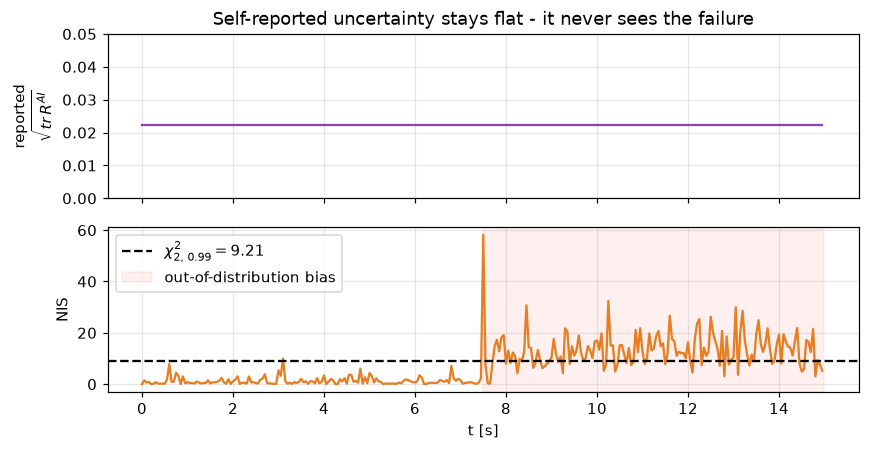

mean NIS  in-distribution: 1.3   |   out-of-distribution: 13.6


In [2]:
import numpy as np, matplotlib.pyplot as plt
L, Ts, V, CHI2 = 2.7, 0.05, 15.0, 9.210
A = np.array([[1, V*Ts], [0, 1]]); E = np.array([0, -V*Ts]); Q = np.diag([1e-4, 1e-4])
rng = np.random.default_rng(1)
x = np.zeros(2); P = np.diag([0.05, 0.02]); true = np.zeros(2)
srep = np.array([0.02, 0.01])                      # reported std - CONSTANT throughout
N = 300; sig, nis = [], []
for k in range(N):
    kappa = 0.012*np.sin(2*np.pi*k*Ts/6)
    true = np.array([true[0] + V*np.sin(true[1])*Ts, true[1] - V*kappa*Ts])
    bias = np.zeros(2) if k < 150 else np.array([0.22, 0.06])   # OOD bias for k >= 150
    y = true + bias + rng.normal(0, srep)
    x = A @ x + E*kappa; P = A @ P @ A.T + Q                     # KF predict (delta = 0)
    S = P + np.diag(srep**2); nu = y - x
    nis.append(float(nu @ np.linalg.solve(S, nu))); sig.append(np.sqrt((srep**2).sum()))
    Kg = P @ np.linalg.inv(S); x = x + Kg @ nu; P = (np.eye(2) - Kg) @ P

t = np.arange(N)*Ts
fig, ax = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True)
ax[0].plot(t, sig, color="#8e44ad"); ax[0].set_ylim(0, 0.05)
ax[0].set_ylabel("reported\n$\\sqrt{tr\\,R^{AI}}$")
ax[0].set_title("Self-reported uncertainty stays flat - it never sees the failure")
ax[1].plot(t, nis, color="#e67e22")
ax[1].axhline(CHI2, ls="--", color="k", label="$\\chi^2_{2,\\,0.99}=9.21$")
ax[1].axvspan(150*Ts, N*Ts, color="red", alpha=0.06, label="out-of-distribution bias")
ax[1].set_ylabel("NIS"); ax[1].set_xlabel("t [s]"); ax[1].legend(loc="upper left")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("mean NIS  in-distribution: %.1f   |   out-of-distribution: %.1f"
      % (np.mean(nis[:150]), np.mean(nis[150:])))

The top panel is what an uncertainty-threshold rule watches: it never moves, so
that rule stays silent through the entire failure. The bottom panel is the
model-based NIS - it crosses the $\chi^2$ line as soon as the measurement stops
agreeing with the physics. A monitor built only on the network's self-reported
confidence is blind here; a monitor that also checks *consistency with a model* is
not. Everything else in the course - the controller, the ODD, the integrity score,
the shared control - exists to turn this detection into safe *action*.

## The three architectures, precisely

The capstone (notebook 08) compares three ways of using the *same* perception,
stated here as decision rules.

**Naive AI** - trust completely:
$$ \hat x_k = \hat y_k,\qquad u_k = \pi(\hat x_k),\qquad \lambda_k = 1. $$

**Hard handover** - switch fully to the driver when the *reported* uncertainty
crosses a threshold $\tau$:
$$ \lambda_k = \begin{cases} 1 & \mathrm{tr}\,R_k^{AI} \le \tau \\[2pt] 0 & \text{otherwise.} \end{cases} $$
As the experiment above shows, this never triggers on the confident-but-wrong
out-of-distribution case.

**Proposed (integrity-aware)** - filter the estimate, fuse the integrity score (5),
then share authority smoothly and contract the operating envelope:
$$ u_k = \delta^{ff}_k + \lambda_k\,\mathrm{fb}_A(\hat x_k) + (1-\lambda_k)\,\delta^{H}_k,
   \qquad \lambda_k = \Phi(I_k, W_k),\qquad v^{ref}_k = v_{nom}\,(0.4 + 0.6\,I_k), $$
where $W_k$ is the driver workload and $\delta^{H}_k$ the human command (notebook 07).
The map-based feed-forward $\delta^{ff}_k$ is always applied; only the *feedback*
authority is arbitrated (notebook 02 explains why).

## Roadmap

| # | Notebook | You build / learn | Key equations |
|---|----------|-------------------|---------------|
| 01 | `01_vehicle_model` | Kinematic lane-error model; discretisation; linearisation; controllability | (1) |
| 02 | `02_lqr_control` | LQR from the Riccati equation; curvature feed-forward; gain scheduling | (3) |
| 03 | `03_perception_and_rendering` | Pinhole camera; synthetic lane images; realistic degradation | (2) |
| 04 | `04_uncertainty_ensembles` | Aleatoric vs epistemic uncertainty; deep ensembles | $\Sigma^{AI}$ |
| 05 | `05_kalman_and_nis` | Kalman filter; innovation; the NIS consistency test | (4) |
| 06 | `06_odd_and_integrity` | Operational design domain; fusing signals into integrity | (5) |
| 07 | `07_shared_control` | Human driver model; authority arbitration; speed contraction | $\lambda_k$ |
| 08 | `08_capstone_closed_loop` | Everything together: 3 methods x 4 scenarios | all |
| 09 | `09_advanced_ideas` | CUSUM change detection; conformal prediction; research directions | - |

Each concept notebook ends with short exercises. **Prerequisites:** basic linear
algebra, probability, and Python. No prior control-theory or deep-learning
background is assumed. **Setup:** `pip install -r requirements.txt`, then open the
notebooks in order.

## Notation

| symbol | meaning |
|--------|---------|
| $x=[e_y,\,e_\psi]^\top$ | lateral offset [m], heading error [rad] |
| $u=\delta$ | steering angle [rad] |
| $\kappa$ | road curvature [1/m] |
| $v,\;L,\;T_s$ | speed [m/s], wheelbase [m], sample time [s] |
| $\mathcal{I}_k,\;c_k$ | camera image and its conditions |
| $\hat y_k$ | perception estimate of the state |
| $R^{AI}_k,\;\Sigma^{AI}_k$ | reported / ensemble (epistemic) covariance |
| $\hat x_{k\mid k-1},\;P_{k\mid k-1}$ | Kalman one-step prediction and its covariance |
| $\nu_k,\;S_k$ | innovation and innovation covariance |
| $\mathrm{NIS}_k$ | normalised innovation squared, eq. (4) |
| $I_k\in[0,1]$ | integrity score, eq. (5) |
| $\lambda_k\in[0,1]$ | automation authority |
| $W_k$ | driver workload |

## References

**Automation levels and operational domain**
1. SAE International. *Taxonomy and Definitions for Terms Related to Driving Automation Systems for On-Road Motor Vehicles.* Standard J3016_202104, 2021.

**Estimation, innovations and fault detection**
2. R. E. Kalman. *A New Approach to Linear Filtering and Prediction Problems.* Journal of Basic Engineering, 82(1):35-45, 1960. doi:10.1115/1.3662552
3. Y. Bar-Shalom, X.-R. Li, T. Kirubarajan. *Estimation with Applications to Tracking and Navigation.* Wiley, 2001. (NIS / measurement consistency and chi-square gating.)
4. R. K. Mehra, J. Peschon. *An innovations approach to fault detection and diagnosis in dynamic systems.* Automatica, 7(5):637-640, 1971. doi:10.1016/0005-1098(71)90028-8
5. A. S. Willsky. *A survey of design methods for failure detection in dynamic systems.* Automatica, 12(6):601-611, 1976. doi:10.1016/0005-1098(76)90041-8

**Uncertainty in learned models**
6. B. Lakshminarayanan, A. Pritzel, C. Blundell. *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles.* NeurIPS, 2017. arXiv:1612.01474
7. A. Kendall, Y. Gal. *What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision?* NeurIPS, 2017. arXiv:1703.04977
8. A. N. Angelopoulos, S. Bates. *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification.* Foundations and Trends in ML, 2023. arXiv:2107.07511 (see also V. Vovk, A. Gammerman, G. Shafer, *Algorithmic Learning in a Random World*, Springer, 2005.)

**Monitoring for automated driving**
9. P. Antonante, H. Nilsen, L. Carlone. *Monitoring of Perception Systems: Deterministic, Probabilistic, and Learning-based Fault Detection and Identification.* Artificial Intelligence, 2022. arXiv:2205.10906
10. H. Y. Yatbaz, M. Dianati, K. Koufos, R. Woodman. *Integrity Monitoring of 3D Object Detection in Automated Driving Systems.* IEEE ITSC, 2024. arXiv:2405.07600
11. T. Charmet, V. Berge-Cherfaoui, J. Guzman, A. Armand. *Operational Design Domain Monitoring with Uncertain Measurements.* IEEE ITSC, 2024. doi:10.1109/ITSC58415.2024.10919733

**Shared human-vehicle control and trust**
12. R. Luo et al. *A Workload Adaptive Haptic Shared Control Scheme for Semi-Autonomous Driving.* Accident Analysis & Prevention, 2020. arXiv:2004.00167
13. D. A. Abbink, M. Mulder, E. R. Boer. *Haptic shared control: smoothly shifting control authority?* Cognition, Technology & Work, 14:19-28, 2012. doi:10.1007/s10111-011-0192-5
14. N. Monsaingeon, L. Caroux, S. Langlois, C. Lemercier. *Multimodal interface and reliability displays: effect on attention, mode awareness, and trust in partially automated vehicles.* Frontiers in Psychology, 2023. doi:10.3389/fpsyg.2023.1107847

**Change detection and the origin of "integrity"**
15. E. S. Page. *Continuous Inspection Schemes.* Biometrika, 41(1/2):100-115, 1954. (CUSUM; used in notebook 09.)
16. R. G. Brown. *A Baseline GPS RAIM Scheme and a Note on the Equivalence of Three RAIM Methods.* Navigation, 39(3):301-316, 1992. (Integrity monitoring in aviation/GNSS.)